# MODUL 2 EKUALISASI DAN SPESIFIKASI HISTOGRAM

In [817]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

## LIBRARY

#### Kode tersebut merupakan kode untuk mengimport library yang dibutuhkan, seperti OpenCV, Matplotlib.pyplot, dan NumPy:
- Library OpenCV digunakan untuk melakukan berbagai operasi citra seperti membaca, menampilkan, memproses, dan memodifikasi, namun pada jurnal kali ini hanya digunakan untuk membaca dan mengubah citra menjadi grayscale.
- NumPy digunakan untuk representasi citra dalam bentuk matriks array, dan pada jurnal kali ini digunakan untuk melalukan operasi pada matriks dan manipulasi piksel.
- Matplotlib digunakan untuk menampilkan citra hasil pemrosesan berbagai tahap proses

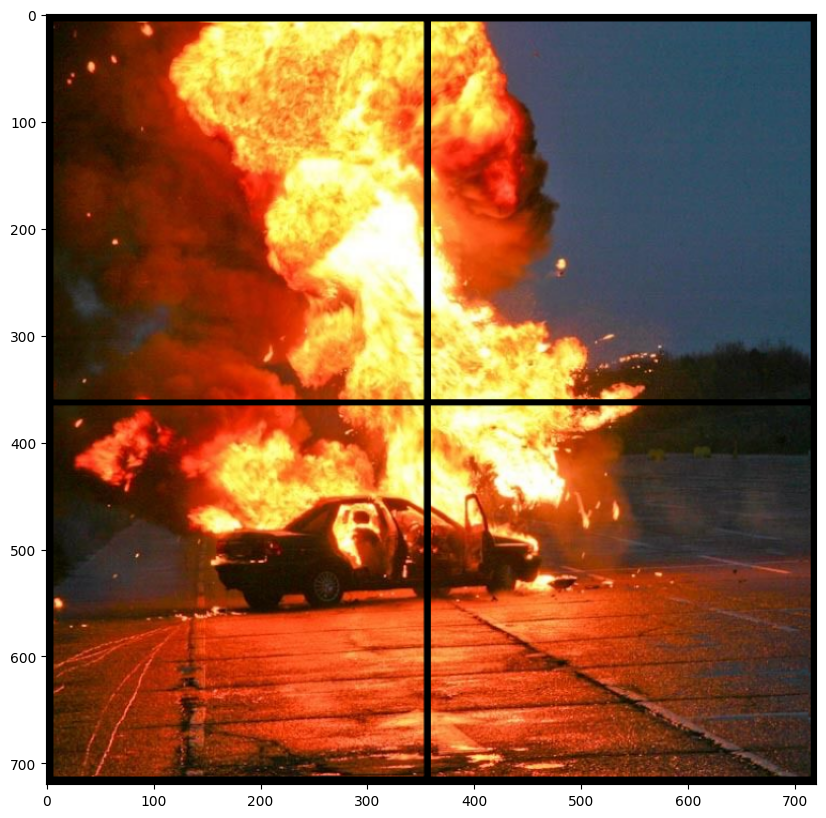

In [852]:
meledak = cv.imread('Assets/Meledak.png')
meledakRGB = cv.cvtColor(meledak, cv.COLOR_BGR2RGB)

plt.figure(figsize=(10, 10))
plt.imshow(meledakRGB)

#### Membaca Gambar dan Mengubahnya Menjadi RGB kemudian Menampilkannya

Membaca citra dengan menggunakan `cv.imread` dan mengubah citra tersebut ke RGB dengan menggunakan `cv.cvtColor(, cv.COLOR_BGR2RGB)` `menampilkannya menggunakan `plt.imshow`.

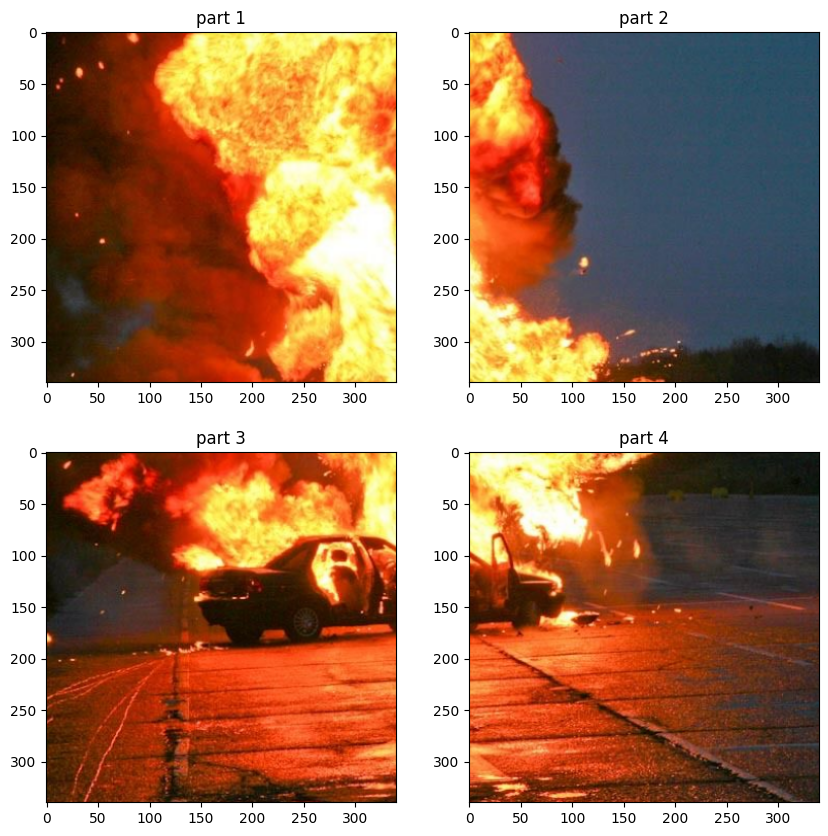

In [819]:
meledak1 = meledakRGB[10:350, 10:350]
meledak2 = meledakRGB[10:350, 370:710]
meledak3 = meledakRGB[370:710, 10:350]
meledak4 = meledakRGB[370:710, 370:710]

plt.figure(figsize=(10, 10))

plt.subplot(2, 2, 1)
plt.title('part 1')
plt.imshow(meledak1)

plt.subplot(2, 2, 2)
plt.title('part 2')
plt.imshow(meledak2)

plt.subplot(2, 2, 3)
plt.title('part 3')
plt.imshow(meledak3)

plt.subplot(2, 2, 4)
plt.title('part 4')
plt.imshow(meledak4)



#### Memotong Citra kemudian Menampilkannya

Memotong citra dengan cara manual `[:, :]` berdasarkan baris dan kolom, di sini saya memotong nya menjadi 4 bagian sesuai dengan instruksi soal, yang di mana untuk part1 barisnya dari piksel 10 - 350 dan kolomnya dari piksel 10 - 350, part2 barisnya dari piksel 10 - 350 dan kolomnya dari piksel 370 - 710, part3 barisnya dari piksel 370 - 710 dan kolomnya dari piksel 10 - 350, serta terakhir part4 barisnya dari piksel 370 - 710 dan kolomnya dari piksel 370 - 710. Kemudian menampilkan keempat part menggunakan `plt.imshow()`

In [853]:
def merge(citra1, citra2, orientation='H'): 
     
    if orientation == 'H':   
        tinggi = max(citra1.shape[0], citra2.shape[0]) 
        lebar_total = citra1.shape[1] + citra2.shape[1] 
         
        if len(citra1.shape) == 2: 
            gabungan = np.zeros((tinggi, lebar_total), dtype=citra1.dtype) 
        else: 
            gabungan = np.zeros((tinggi, lebar_total, citra1.shape[2]), dtype=citra1.dtype) 
         
        gabungan[0:citra1.shape[0], 0:citra1.shape[1]] = citra1 
        gabungan[0:citra2.shape[0], citra1.shape[1]:citra1.shape[1]+citra2.shape[1]] = citra2 
         
    else:   
        tinggi_total = citra1.shape[0] + citra2.shape[0] 
        lebar = max(citra1.shape[1], citra2.shape[1]) 
         
        if len(citra1.shape) == 2: 
            gabungan = np.zeros((tinggi_total, lebar), dtype=citra1.dtype) 
        else: 
            gabungan = np.zeros((tinggi_total, lebar, citra1.shape[2]), dtype=citra1.dtype) 
         
        gabungan[0:citra1.shape[0], 0:citra1.shape[1]] = citra1 
        
        gabungan[citra1.shape[0]:citra1.shape[0]+citra2.shape[0], 0:citra2.shape[1]] = citra2 
     
    return gabungan

#### Fungsi Menggabungkan Dua Citra Secara Horizontal atau Vertikal

Fungsi ini digunakan untuk `menggabungkan dua buah citra menjadi satu`. Terdapat dua mode penggabungan yaitu `horizontal dan vertikal`. Untuk penggabungan `horizontal`, saya melakukannya dengan cara menentukan `tinggi kanvas` sebesar `nilai maksimum tinggi kedua citra` agar muat menampung `keduanya`, dan `lebar kanvas` sebagai `jumlah lebar` kedua citra karena gambar `berjejer ke samping`. Kemudian `image1 diletakkan di sisi kiri kanvas`, dan `image2 diletakkan tepat di sebelah kanannya mulai dari kolom sebesar lebar image1`. Untuk penggabungan `vertikal`, saya melakukannya dengan cara menentukan `tinggi kanvas` sebagai `jumlah tinggi kedua citra` karena `gambar bertumpuk ke bawah`, dan `lebar kanvas sebesar nilai maksimum lebar kedua citra` agar muat menampung keduanya. Kemudian `image1 diletakkan di bagian atas kanvas`, dan `image2 diletakkan tepat di bawahnya mulai dari baris sebesar tinggi image1`.

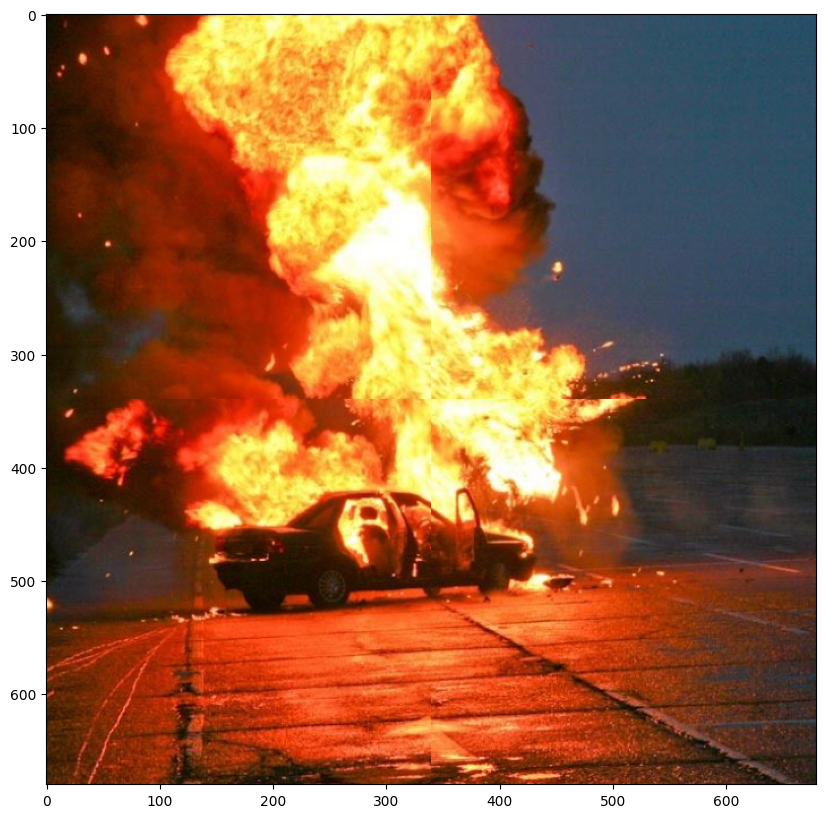

In [821]:
mergeA = merge(meledak1, meledak2, 'H')
mergeB = merge(meledak3, meledak4, 'H')
meledakM = merge(mergeA, mergeB, 'V')

plt.figure(figsize=(10, 10))
plt.imshow(meledakM)

#### Menggabungkan Lagi Keempat Part yang Telah Dicrop Menjadi Satu dengan Fungsi merge() kemudian Menampilkannya

Menggabungkan keempat part dengan cara, menggabungkan terlebih dahulu dua part di atas yaitu part 1 dan part 2 serta menggabungkan dua part di bawah yaitu part 3 dan part 4 dengan menggunakan fungsi merge() dengan orientasi atau mode H. Kemudian menggabungkan kembali hasil dari merge-merge tersebut menjadi satu gambar utuh dengan orientasi atau mode V (selain H) dan menyimpannya dalam variabel meledakM

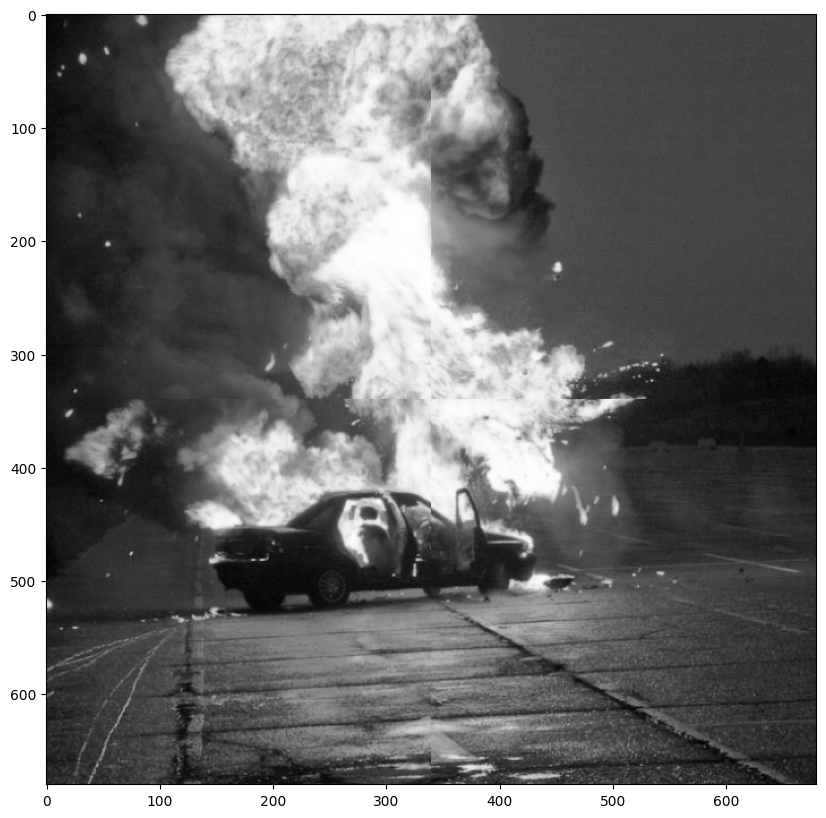

In [822]:
meledakG = cv.cvtColor(meledakM, cv.COLOR_RGB2GRAY)

plt.figure(figsize=(10, 10))
plt.imshow(meledakG, cmap = 'gray')

#### Mengubah Citra menjadi Grayscale kemudian Menampilkannya

Mengubah citra meledakM yang telah digabung menjadi satu ke grayscale dengan menggunakan `cv.cvtColor(, cv.COLOR_BGR2GRAY)` dan menyimpannya dalam variabel `meledakG` kemudian menampilkannya menggunakan `plt.imshow`

In [823]:
def ekualisasi(citra):
    height, width = citra.shape
    hist = np.zeros(256, dtype=int)

    for i in range(height):
        for j in range(width):
            hist[citra[i, j]] += 1

    cdf = np.zeros(256, dtype=int)
    cdf[0] = hist[0]

    for i in range(1, 256):
        cdf[i] = cdf[i - 1] + hist[i]

    cdf_normal = np.round(cdf * 255 / (height * width)).astype(np.uint8)
    hasil = np.zeros_like(citra, dtype=np.uint8)

    for i in range(height):
        for j in range(width):
            hasil[i, j] = cdf_normal[citra[i, j]]

    return hasil

#### Fungsi Ekualisasi Histogram Citra

Fungsi ini digunakan untuk `meningkatkan kontras` sebuah citra melalui teknik `histogram equalization`. Terdapat beberapa tahapan utama yaitu `menghitung histogram`, `menghitung CDF`, `normalisasi CDF`, dan `memetakan ulang nilai piksel`.

Pertama, menghitung `histogram citra` dengan cara membuat array `hist berukuran 256`, lalu `menelusuri setiap piksel` pada citra dan `menambah jumlah` di hist pada indeks yang sesuai dengan nilai piksel tersebut, sehingga hist menyimpan `seberapa sering tiap nilai intensitas muncul` di seluruh citra.

Kedua, menghitung `Cumulative Distribution Function (CDF)` dengan cara membuat array `cdf` berukuran 256, lalu `mengakumulasi nilai histogram` secara berurutan sehingga `cdf[i]` menyimpan `jumlah piksel dengan nilai 0 hingga i`.

Ketiga, melakukan `normalisasi CDF` ke rentang 0–255 dengan rumus `cdf * 255 / (height * width)`, menghasilkan `cdf_normal` yang berfungsi sebagai `tabel pemetaan nilai piksel lama ke nilai piksel baru`.

Keempat, `memetakan ulang setiap piksel` pada citra dengan cara `mengganti nilai piksel lama` dengan nilai dari `cdf_normal` di indeks yang sesuai, sehingga menghasilkan citra `hasil` dengan `distribusi kecerahan yang lebih merata`.

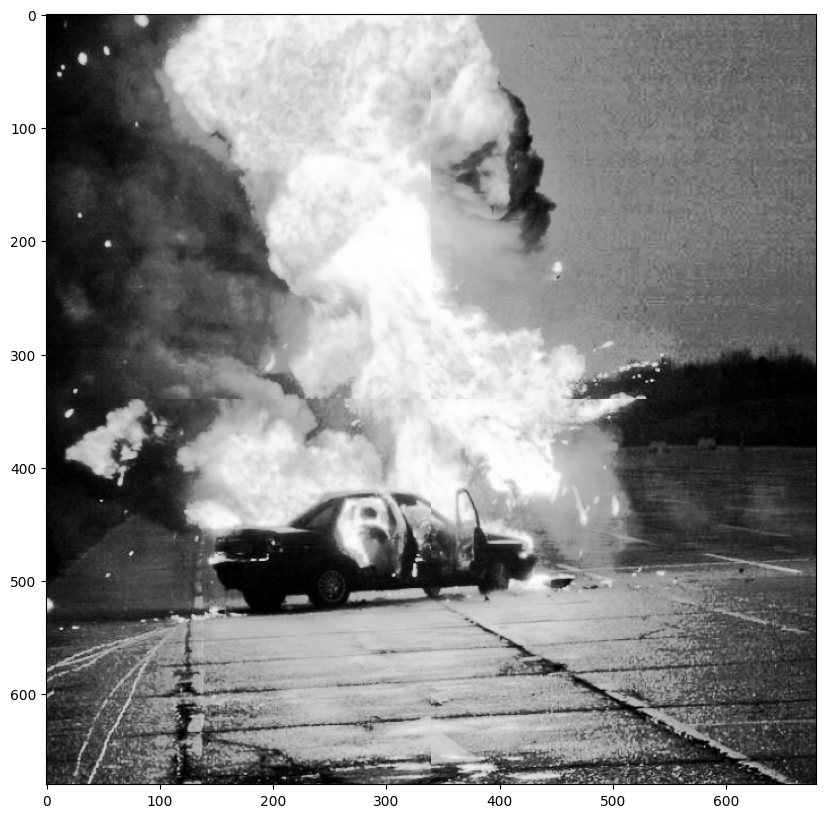

In [ ]:
meledakE = ekualisasi(meledakG)
plt.figure(figsize=(10, 10))
plt.imshow(meledakE, cmap = 'gray')

#### Mengekualisasi meledakG dan menyimpannya dalam variabel meledakE kemudian menampilkannya

Proses ekualisasi ini dilakukan pada `meledakG` untuk `meningkatkan kontras citra grayscale` 
dengan memanggil fungsi `ekualisasi(meledakG)`, lalu hasilnya disimpan ke variabel `meledakE`. 
Kemudian citra hasil ekualisasi ditampilkan menggunakan `imshow`.

In [854]:
def buat_hist(citra): 
    histogram = [0] * 256 
 
    height = len(citra) 
    width = len(citra[0]) if height > 0 else 0 
    for i in range(height): 
        for j in range(width): 
            val = int(citra[i][j])   
            histogram[val] += 1   
 
    return histogram 
def plot_histogram(histogram, title, ImgColor, label): 
    plt.xlabel("Intensitas Piksel") 
    plt.title(title) 
    plt.ylabel("Jumlah Piksel") 
    plt.bar(range(256), histogram, color=ImgColor, width=0.8, label = label) 

#### Fungsi Membuat dan Menampilkan Histogram Citra

Terdapat dua fungsi di sini yaitu `buat_hist` untuk `menghitung histogram` dan 
`plot_histogram` untuk `menampilkannya sebagai grafik batang`.

Pada fungsi `buat_hist`, pertama dibuat array `histogram berukuran 256` sesuai rentang 
nilai piksel, lalu `tinggi dan lebar citra` diambil menggunakan `len()`. Kemudian setiap 
piksel ditelusuri, `nilai intensitasnya diambil` dan dikonversi ke `int`, lalu digunakan 
sebagai `indeks array histogram` untuk `menambah jumlahnya`, sehingga histogram menyimpan 
`seberapa sering tiap nilai intensitas muncul` di seluruh citra.

Pada fungsi `plot_histogram`, histogram ditampilkan sebagai `grafik batang` menggunakan 
`plt.bar` dengan sumbu X sebagai `intensitas piksel (0–255)` dan sumbu Y sebagai 
`jumlah piksel`. Selain itu juga ditambahkan `judul grafik`, `warna batang`, dan `label` 
sesuai parameter yang diberikan.

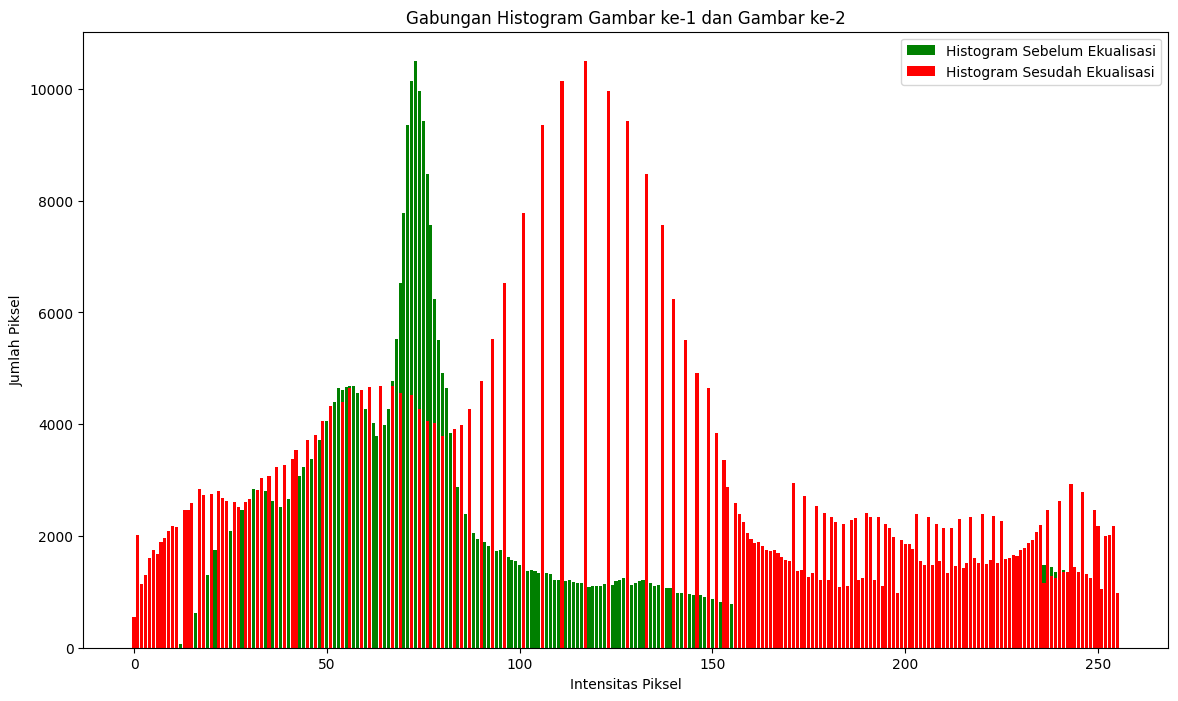

In [826]:
plt.figure(figsize=(14, 8))

meledakHG = buat_hist(meledakG)
meledakHE = buat_hist(meledakE)
plot_histogram(meledakHG, 'Gabungan Histogram Gambar ke-1 dan Gambar ke-2', 'green', 'Histogram Sebelum Ekualisasi')
plot_histogram(meledakHE, 'Gabungan Histogram Gambar ke-1 dan Gambar ke-2', 'red', 'Histogram Sesudah Ekualisasi')
plt.legend()

#### Menampilkan Histogram Gabungan antara Histpgram Sebelum dan Sesudah Ekualisasi

Proses ini dilakukan untuk `membandingkan distribusi intensitas piksel` sebelum dan sesudah ekualisasi secara visual. Dengan menampilkan kedua histogram dalam `satu grafik yang sama`, kita bisa langsung melihat `seberapa besar perubahan` yang dihasilkan oleh proses ekualisasi terhadap citra.

#### Analisis Perbandingan Kedua Histogram

**Histogram Hijau (Sebelum Ekualisasi)**, distribusi piksel `menumpuk di rentang intensitas 50–150`, dengan puncak tertinggi di sekitar 
`intensitas 70` yang mencapai lebih dari `10.000 piksel`. Ini menandakan bahwa citra asli `didominasi oleh piksel gelap hingga sedang`, sehingga citra terlihat `kurang kontras dan cenderung gelap`.

**Histogram Merah (Sesudah Ekualisasi)**, distribusi piksel menjadi `jauh lebih menyebar` ke seluruh rentang intensitas `0–255`. 
Tidak ada lagi satu puncak yang sangat dominan, melainkan `tersebar lebih merata` meski dengan beberapa lonjakan. Ini menandakan bahwa ekualisasi berhasil `mendistribusikan ulang nilai piksel` sehingga citra memiliki `kontras yang lebih baik`.

Ekualisasi histogram berhasil mengubah citra yang sebelumnya `terpusat di rentang sempit` menjadi citra dengan `sebaran intensitas yang lebih luas`, yang berarti detail pada area `gelap maupun terang` pada citra menjadi `lebih terlihat dan jelas`.

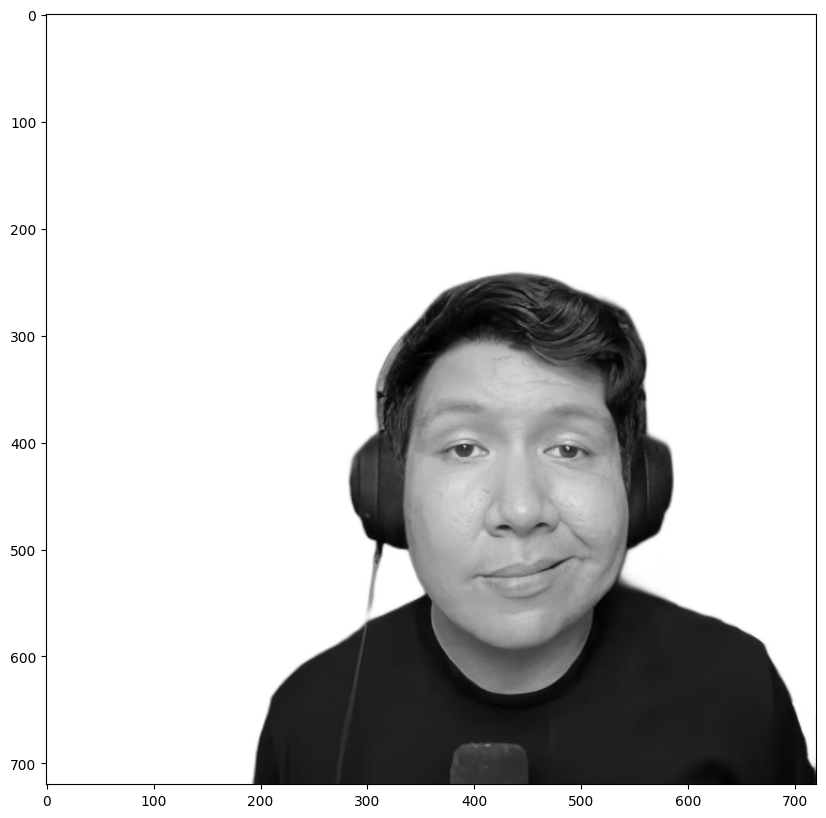

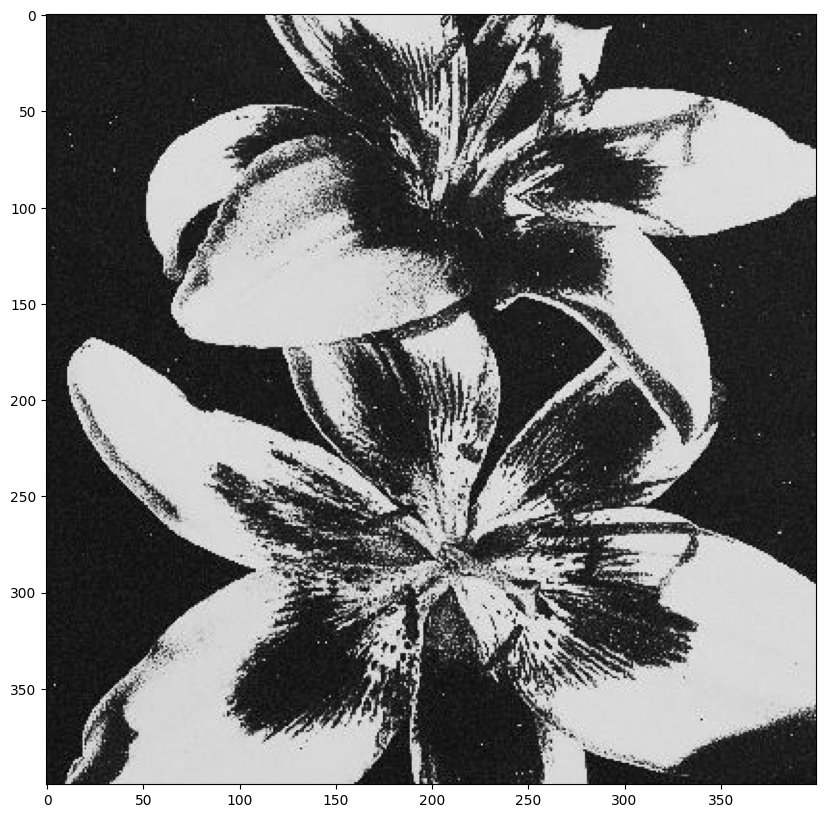

In [855]:
windut = cv.imread('Assets/Windut.png')
windutG = cv.cvtColor(windut, cv.COLOR_BGR2GRAY)
bireng = cv.imread('Assets/Bunga.png')
birengG = cv.cvtColor(bireng, cv.COLOR_BGR2GRAY)

plt.figure(figsize=(10, 10))

plt.imshow(windutG, cmap = 'gray')
plt.show()

plt.figure(figsize=(10, 10))

plt.imshow(birengG, cmap = 'gray')
plt.show()

#### Membaca Windut.png dan Bunga.png kemudian Mengubahnya Menjadi Grayscale dan Menampilkannya

Membaca citra dengan menggunakan `cv.imread` dan mengubah citra `Windut.png` yang telah disimpah dalam variabel `windut` dan citra `Bunga.png` yang telah disimpan dalam variabel `bireng` ke `Grayscale` dengan menggunakan `cv.cvtColor(, cv.COLOR_BGR2GRAY)` dan menyimpannya dalam variabel `windutG` dan `birengG` kemudian menampilkannya menggunakan `plt.imshow`.

In [828]:
def spesifikasi_histogram(citra_asal, citra_target):
    hist_asal = np.zeros(256, dtype=int)
    hist_target = np.zeros(256, dtype=int)

    for i in range(citra_asal.shape[0]):
        for j in range(citra_asal.shape[1]):
            hist_asal[citra_asal[i, j]] += 1

    for i in range(citra_target.shape[0]):
        for j in range(citra_target.shape[1]):
            hist_target[citra_target[i, j]] += 1

    cdf_asal = np.zeros(256, dtype=float)
    cdf_target = np.zeros(256, dtype=float)

    cdf_asal[0] = hist_asal[0]
    cdf_target[0] = hist_target[0]

    for i in range(1, 256):
        cdf_asal[i] = cdf_asal[i - 1] + hist_asal[i]
        cdf_target[i] = cdf_target[i - 1] + hist_target[i]

    cdf_asal = cdf_asal / cdf_asal[-1]
    cdf_target = cdf_target / cdf_target[-1]

    map_hist = np.zeros(256, dtype=np.uint8)

    for i in range(256):
        min_selisih = float('inf')
        best_j = 0
        for j in range(256):
            selisih = abs(cdf_asal[i] - cdf_target[j])
            if selisih < min_selisih:
                min_selisih = selisih
                best_j = j
        map_hist[i] = best_j

    height, width = citra_asal.shape
    hasil = np.zeros((height, width), dtype=np.uint8)

    for i in range(height):
        for j in range(width):
            hasil[i, j] = map_hist[citra_asal[i, j]]

    return hasil

#### Fungsi Spesifikasi Histogram

Fungsi ini digunakan untuk `menyesuaikan distribusi histogram citra asal` agar mendekati `distribusi histogram citra target`. Terdapat beberapa tahapan utama yaitu `menghitung histogram, menghitung CDF, normalisasi CDF, membuat tabel pemetaan, dan memetakan ulang nilai piksel`.

Pertama, menghitung `histogram citra asal dan citra target` dengan cara `menelusuri setiap piksel` pada masing-masing citra dan `menambah cacahan` di array `hist_asal` maupun `hist_target` pada indeks yang sesuai dengan `nilai intensitas pikselnya`.

Kedua, menghitung `CDF (Cumulative Distribution Function)` untuk kedua citra dengan cara `mengakumulasi nilai histogram` secara berurutan sehingga `cdf[i]` menyimpan `jumlah piksel dengan nilai 0 hingga i`.

Ketiga, melakukan `normalisasi CDF` dengan membagi setiap nilai CDF dengan `nilai CDF terakhir` yaitu `cdf[-1]`, sehingga rentang CDF kedua citra menjadi `0.0 hingga 1.0` dan bisa dibandingkan secara adil.

Keempat, membuat `tabel pemetaan map_hist` dengan cara untuk setiap nilai intensitas `i` pada citra asal, dicari nilai `j` pada citra target yang memiliki `selisih CDF terkecil`. Nilai `j` terbaik tersebut disimpan di `map_hist[i]`, sehingga `map_hist` berfungsi sebagai `tabel konversi nilai piksel lama ke nilai piksel baru`.

Kelima, `memetakan ulang setiap piksel` citra asal menggunakan `map_hist`, sehingga menghasilkan citra `hasil` yang distribusi histogramnya `menyerupai distribusi citra target`.

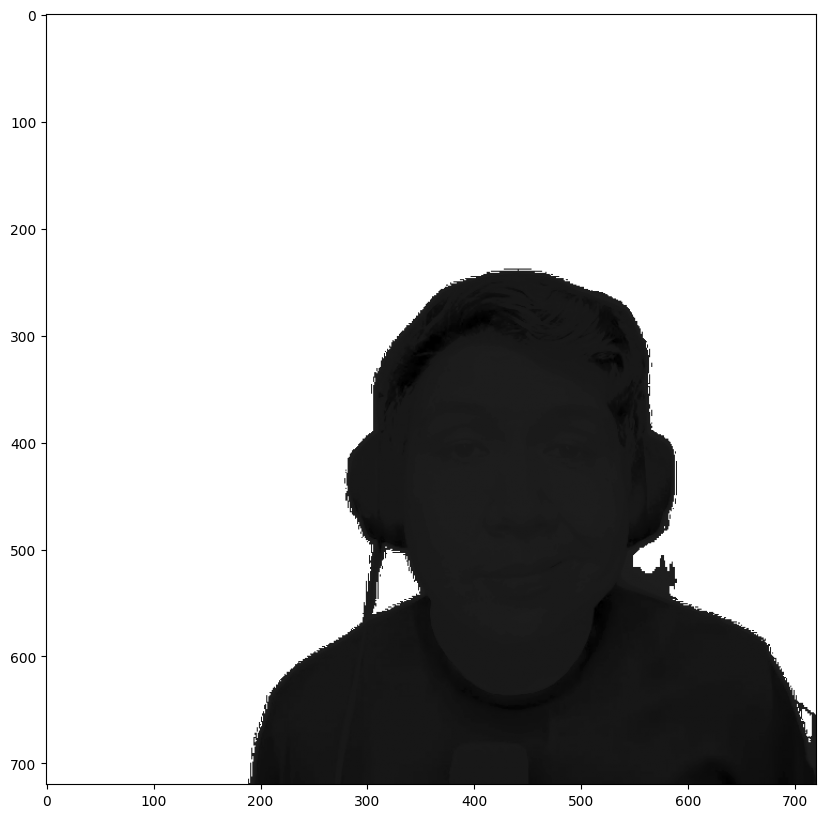

In [829]:
windutS = spesifikasi_histogram(windutG, birengG)

plt.figure(figsize=(10, 10))
plt.imshow(windutS, cmap = 'gray')

#### Melakukan Operasi Spesifikasi Histogram pada Citra windutG Terhadap Citra birengG

Proses ini dilakukan untuk `menyesuaikan tampilan citra windutG` agar memiliki 
`distribusi kecerahan yang menyerupai citra birengG`. Dengan menjadikan `birengG sebagai target`, hasil citra `windutS` diharapkan memiliki `karakteristik kontras dan kecerahan` yang serupa dengan `birengG` yaitu `kontras dan keccerahan yang gelap`, sehingga kedua citra terlihat lebih `seragam dan konsisten` secara visual. Kemudian hasil spesifikasi ditampilkan menggunakan `plt.imshow`

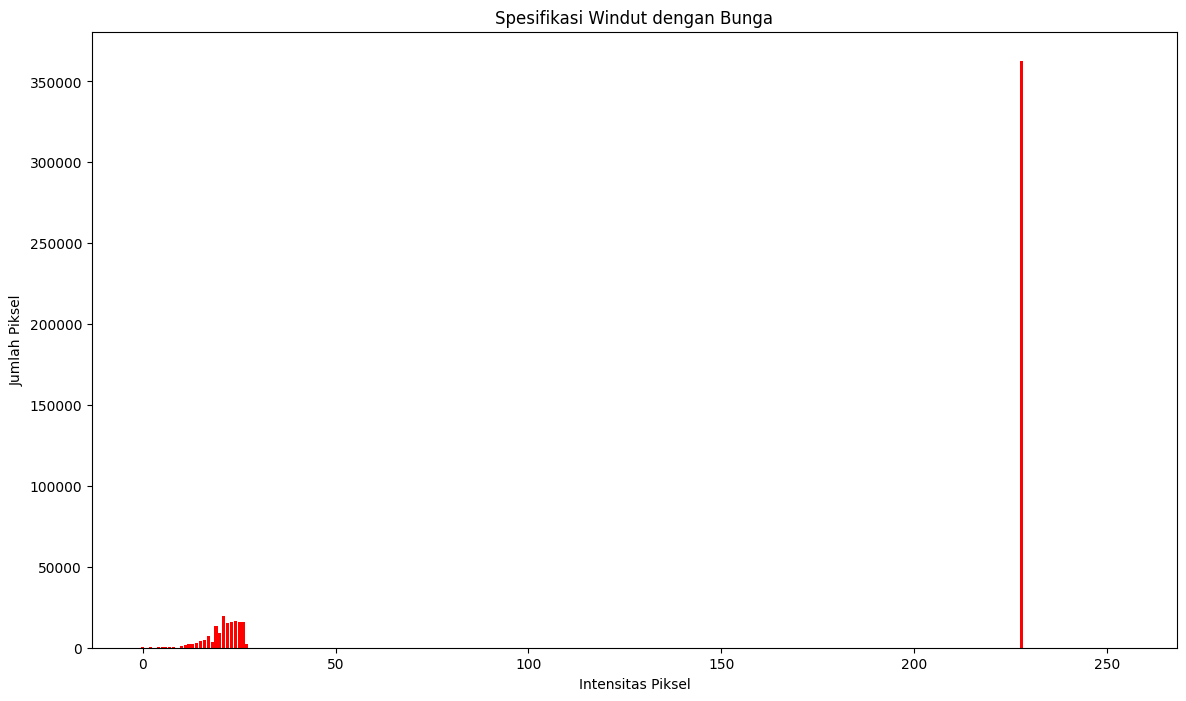

In [830]:
plt.figure(figsize=(14, 8))

windutH = buat_hist(windutS)
plot_histogram(windutH, 'Spesifikasi Windut dengan Bunga', 'red', 'ngasal')

#### Menampilkan Histogram Hasil Spesifikasi Windut dengan Bunga

Dari histogram yang dihasilkan, terlihat bahwa distribusi piksel `sangat tidak merata` dan terdapat `dua kelompok utama` yang sangat mencolok.

**Kelompok Pertama (Intensitas 0–50)**, terdapat sejumlah piksel yang `terkonsentrasi di rentang gelap`, dengan beberapa lonjakan 
kecil di sekitar `intensitas 10–30`. Jumlahnya relatif kecil dibanding kelompok kedua.

**Kelompok Kedua (Intensitas 230an)**, terdapat `satu lonjakan sangat dominan` di sekitar intensitas `230` yang mencapai lebih dari `350.000 piksel`. Ini menandakan bahwa sebagian besar piksel citra `windutS dipetakan ke satu nilai intensitas yang sama`, yaitu intensitas terang mendekati putih.

Hasil ini menunjukkan bahwa spesifikasi histogram antara `windutG dan birengG` menghasilkan pemetaan yang `kurang ideal`, kemungkinan karena `karakteristik distribusi kedua citra yang sangat berbeda` sehingga sebagian besar piksel `menumpuk pada satu nilai target` yang paling mendekati CDF citra referensi. Akibatnya citra hasil terlihat `kehilangan detail` dan `terlalu terang` di sebagian besar area.

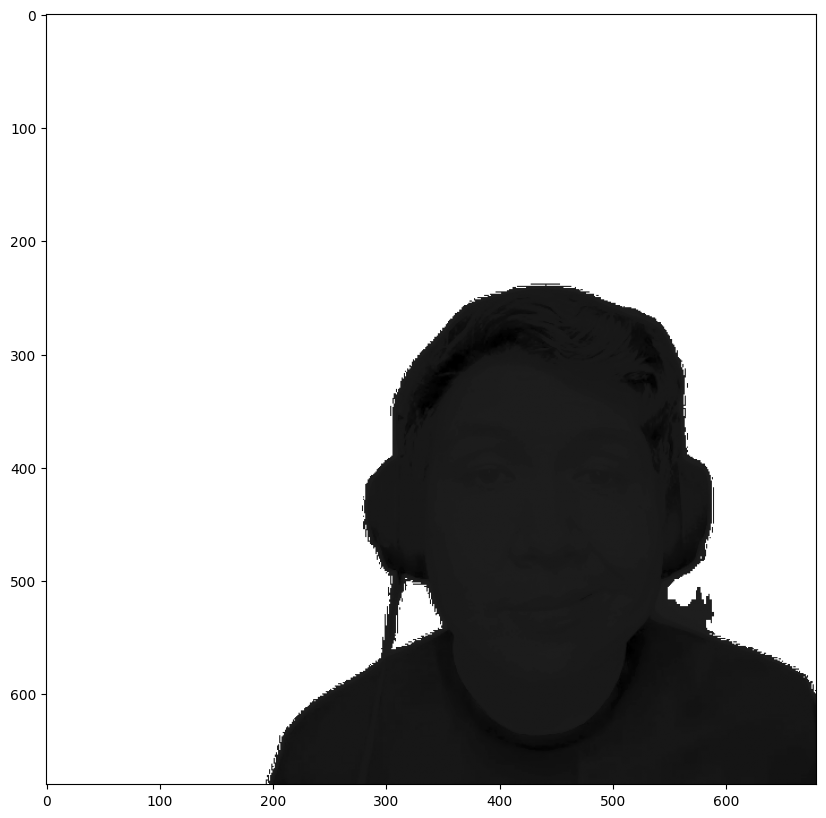

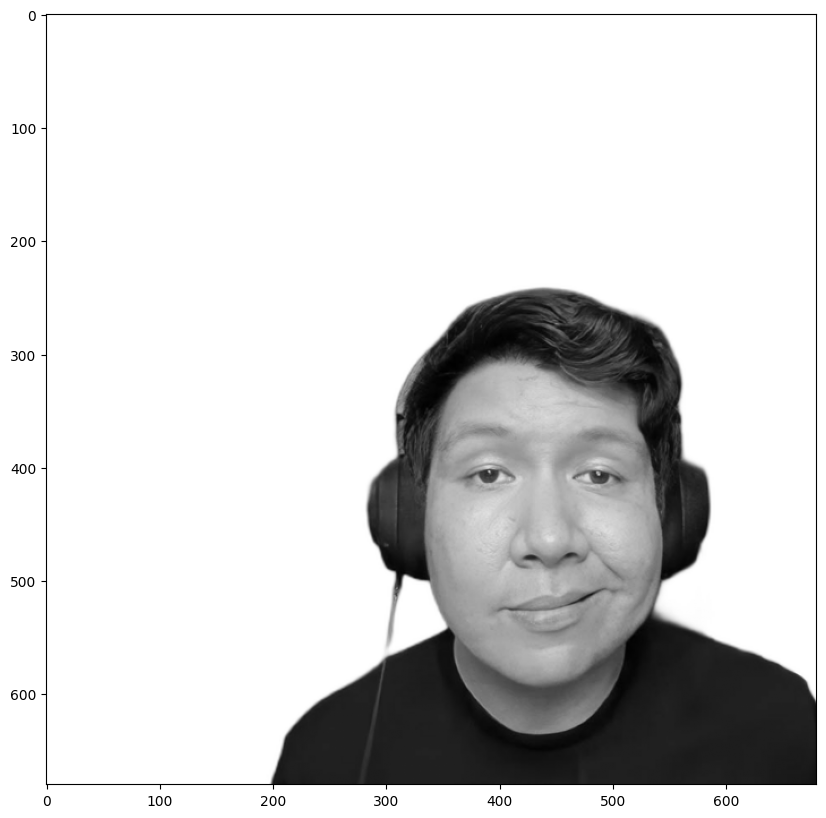

In [857]:
windutS = windutS[0:680, 0:680]
windutG = windutG[0:680, 0:680]

plt.figure(figsize=(10, 10))
plt.imshow(windutS, cmap = 'gray')

plt.figure(figsize=(10, 10))
plt.imshow(windutG, cmap = 'gray')

#### Memotong Citra windutS dan windutG kemudian Menampilkannya

Memotong citra dengan cara manual `[:, :]` berdasarkan baris dan kolom, di sini saya memotong citra `windutG` dan `windutG` dengan `baris` dari piksel `0 -680` dan `kolom` dari piksel `0 - 680` juga. Hal ini saya lakukan untuk membuat kedua citra tersebut memiliki ukuran `680 x 680` untuk kepentingan operasi berikutnya.

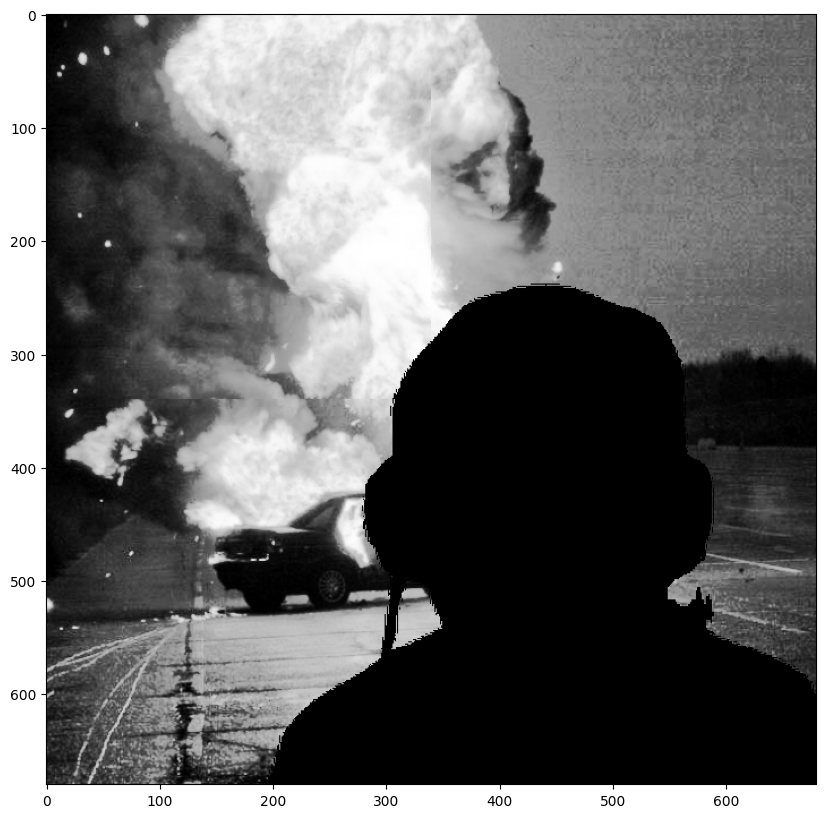

In [832]:
windutM = np.zeros_like(windutS, dtype=int) 
for i in range(windutM.shape[0]): 
    for j in range(windutM.shape[1]): 
        if(windutS[i,j]>50): 
            windutM[i,j] = meledakE[i,j] 
plt.figure(figsize=(10, 10))
plt.imshow(windutM, cmap = 'gray') 

#### Melakukan Operasi Masking pada windutS sebagai foreground dan meledakE sebagai background

Proses ini dilakukan untuk `menggabungkan dua citra` yaitu `windutS dan meledakE` berdasarkan `kondisi nilai piksel` tertentu. Cara kerjanya adalah dengan membuat `kanvas kosong windutM` berukuran sama dengan `windutS`, lalu setiap piksel diperiksa, jika nilai piksel `windutS lebih dari 50` (bukan area gelap), maka piksel tersebut `diambil dari meledakE`, sedangkan jika nilainya `50 ke bawah` maka piksel tetap bernilai `0` (Hitam). Tujuannya adalah untuk `memisahkan area gelap dan terang` pada `windutS` dan menggunakannya sebagai `masker`, sehingga hanya area yang dianggap `cukup terang` yang akan `diisi dengan konten dari meledakE`. Ini merupakan teknik sederhana `image masking` yang memanfaatkan `informasi spesifikasi histogram` sebelumnya untuk `menentukan area mana` pada citra `windutS` yang akan `ditimpa dengan citra meledakE`.

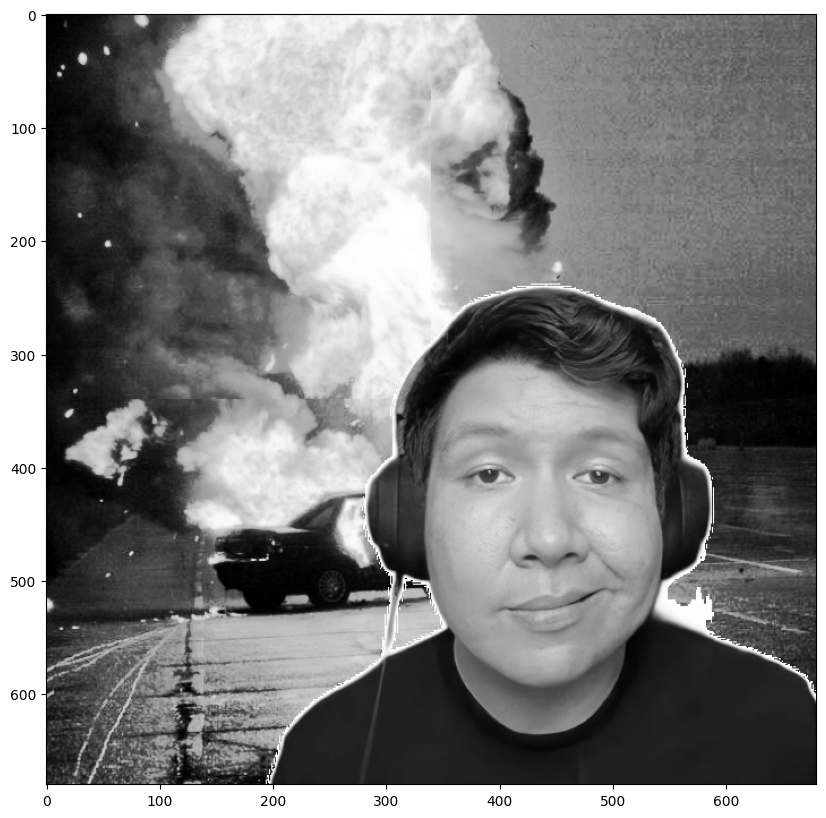

In [833]:
windutMC = windutM.copy() 
for i in range(windutMC.shape[0]): 
    for j in range(windutMC.shape[1]): 
        if(windutS[i,j]<50): 
            windutMC[i,j] = windutG[i,j] 

plt.figure(figsize=(10, 10))
plt.imshow(windutMC, cmap = 'gray') 

#### Mengganti Area Hitam pada windutM dengan Piksel windutG

Proses ini dilakukan untuk `melengkapi citra windutM` yang sebelumnya memiliki `area hitam (nilai 0)` di bagian gelap, dengan cara `mengisi area tersebut menggunakan piksel dari windutG`. Caranya adalah dengan `menyalin windutM ke windutMC` terlebih dahulu agar `citra asli tidak berubah`, lalu setiap piksel diperiksa, jika nilai piksel `windutS kurang dari 50` (area gelap), maka piksel pada `windutMC diisi dengan nilai dari windutG`. Tujuannya adalah untuk menghasilkan citra `windutMC` yang `lengkap tanpa area hitam`, dimana `area terang diisi oleh meledakE` (dari proses masking sebelumnya) dan `area gelap 
diisi oleh windutG` sehingga citra hasil terlihat `lebih natural dan detail tetap terjaga`.

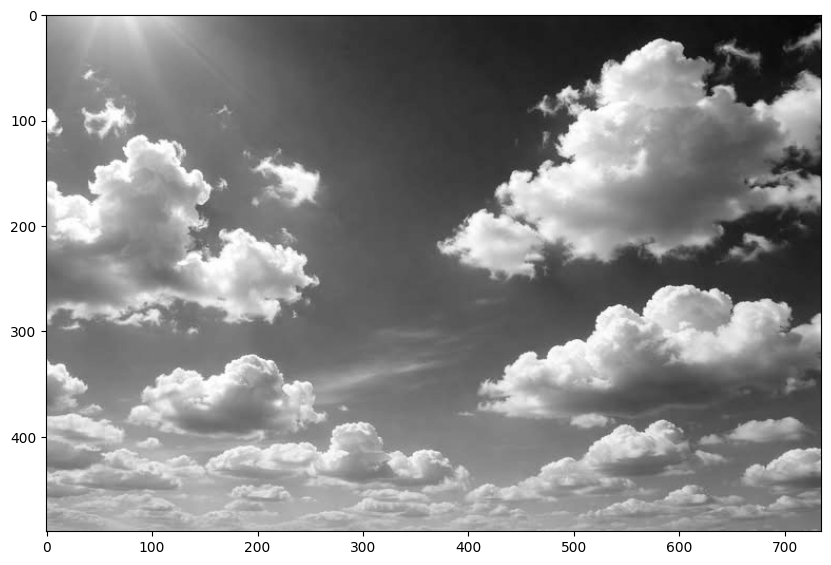

In [858]:
langit = cv.imread('Assets/Langit.png')
langitG = cv.cvtColor(langit, cv.COLOR_BGR2GRAY)

plt.figure(figsize=(10, 10))

plt.imshow(langitG, cmap = 'gray')
plt.show()

#### Membaca Langit.png kemudian Mengubahnya Menjadi Grayscale dan Menampilkannya

Membaca citra dengan menggunakan `cv.imread` dan mengubah citra `Langit.png` yang telah disimpah dalam variabel `langit` ke `Grayscale` dengan menggunakan `cv.cvtColor(, cv.COLOR_BGR2GRAY)` dan menyimpannya dalam variabel `langitG` kemudian menampilkannya menggunakan `plt.imshow`.

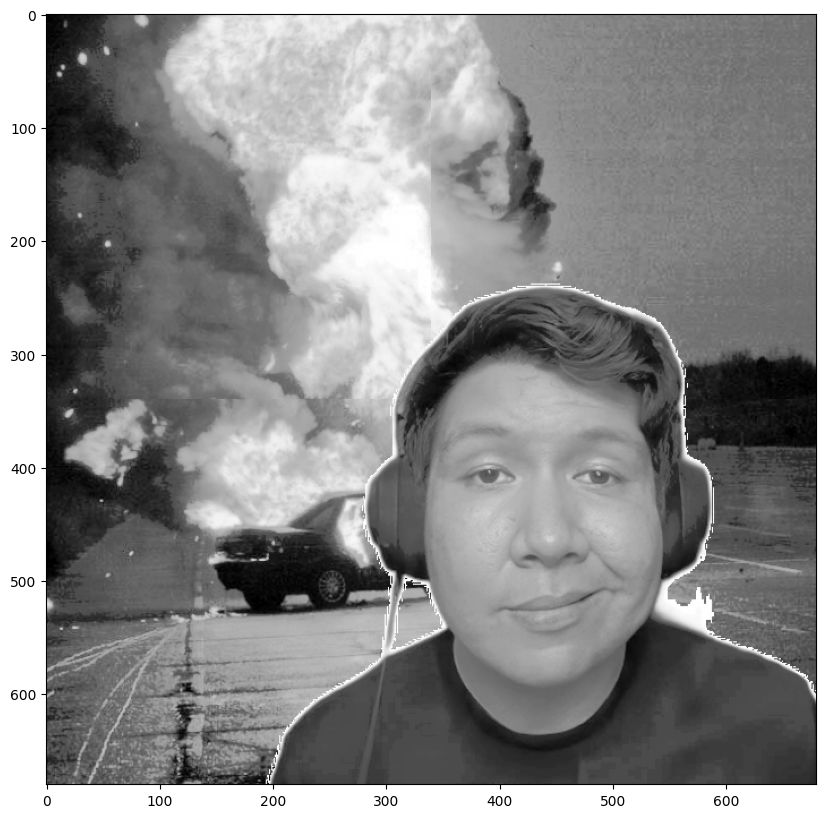

In [835]:
windutFullSenyum = spesifikasi_histogram(windutMC, langitG)

plt.figure(figsize=(10, 10))
plt.imshow(windutFullSenyum, cmap = 'gray')

#### Melakukan Operasi Spesifikasi Histogram pada Citra windutMC Terhadap Citra langitG

Proses ini dilakukan untuk `menyesuaikan tampilan citra windutG` agar memiliki 
`distribusi kecerahan yang menyerupai citra langitG`. Dengan menjadikan `langitG sebagai target`, hasil citra `windutS` diharapkan memiliki `karakteristik kontras dan kecerahan` yang serupa dengan `langitG` yaitu `kontras dan keccerahan yang cerah`, sehingga kedua citra terlihat lebih `seragam dan konsisten` secara visual. Kemudian hasil spesifikasi ditampilkan menggunakan `plt.imshow`

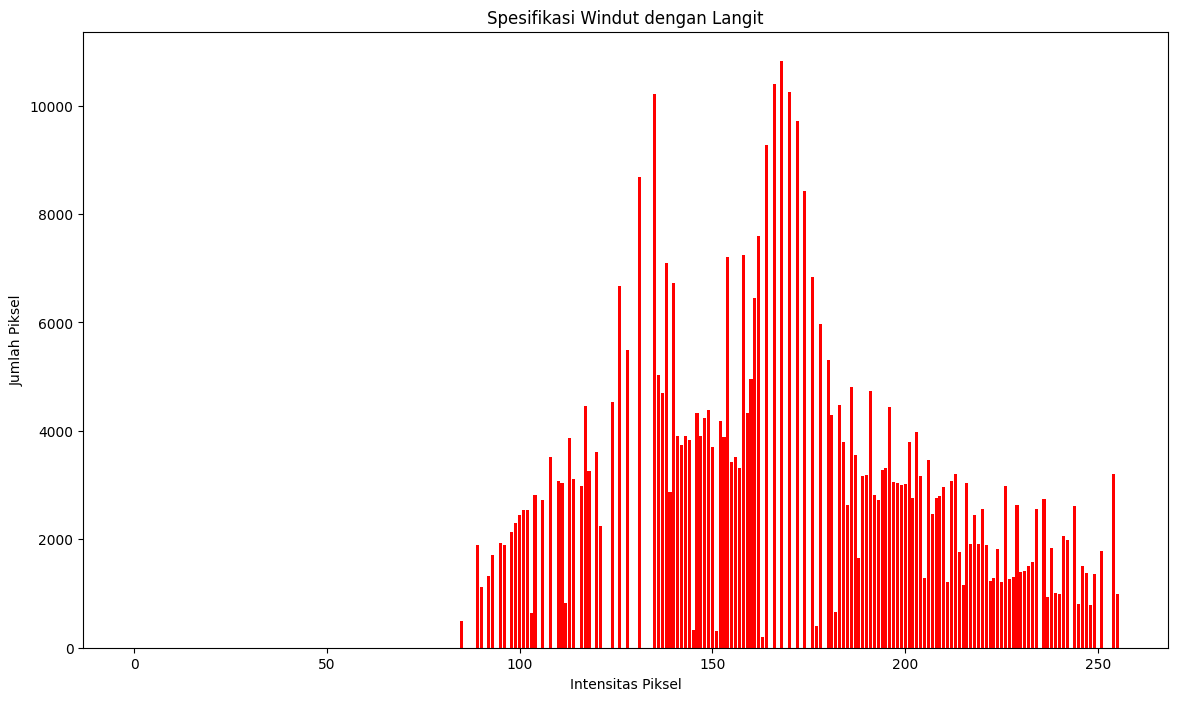

In [836]:
plt.figure(figsize=(14, 8))

windutFullSenyumH = buat_hist(windutFullSenyum)
plot_histogram(windutFullSenyumH, 'Spesifikasi Windut dengan Langit', 'red', 'ngasal')

#### Menampilkan Histogram Hasil Spesifikasi WindutMC dengan LangitG

Berbeda dengan spesifikasi sebelumnya menggunakan citra bunga, hasil spesifikasi dengan citra langit menghasilkan distribusi yang `jauh lebih baik dan merata`.

Piksel `terpusat di rentang intensitas 90–250`, dengan puncak tertinggi di sekitar `intensitas 165–170` yang mencapai lebih dari `10.000 piksel`. Tidak ada lagi `satu lonjakan ekstrem` yang mendominasi seperti sebelumnya, melainkan distribusi `menyebar secara wajar` membentuk pola seperti `kurva lonceng condong ke kanan`. Piksel yang `terdistribusi di rentang menengah hingga terang` menandakan bahwa citra hasil memiliki `kontras yang lebih natural` dan `detail yang lebih terjaga` di seluruh area citra.

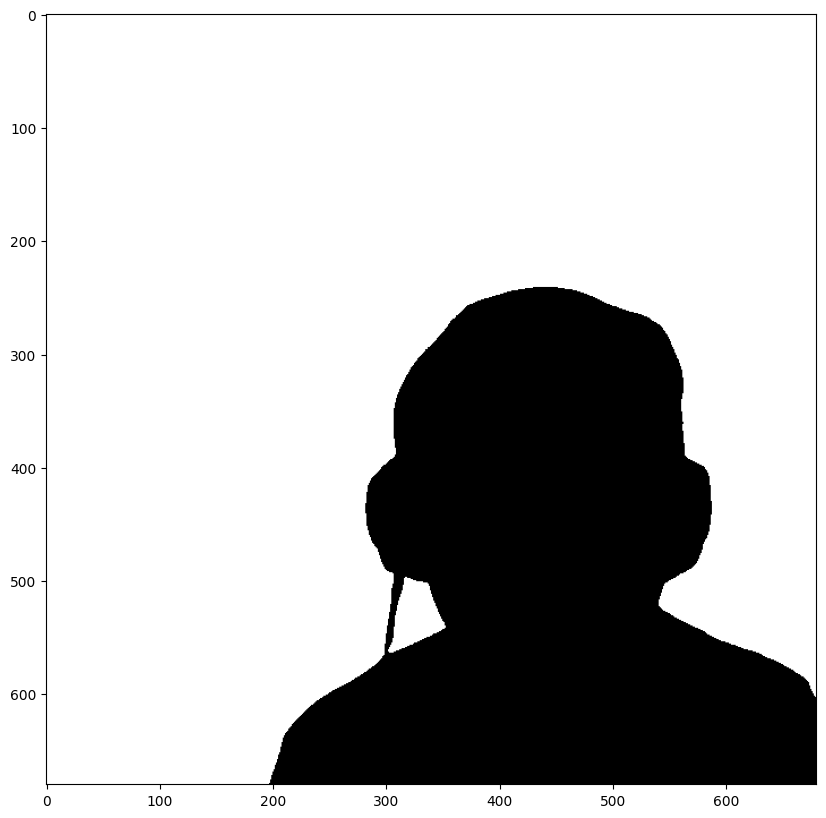

In [859]:
windutP = windut[0:680, 0:680]

def masker(citra, threshold_val):
    h, w, c = citra.shape
    masker = np.zeros((h, w), dtype=np.uint8)
    for i in range(h):
        for j in range(w):
            intensitas = (int(citra[i, j, 0]) + int(citra[i, j, 1]) + int(citra[i, j, 2])) // 3
            if intensitas > threshold_val:
                masker[i, j] = 1 
            else:
                masker[i, j] = 0
                
    return masker

mask = masker(windutP, 240)

plt.figure(figsize=(10, 10))
plt.imshow(mask, cmap = 'gray')

#### Memotong Citra dan Membuat Masker Berdasarkan Threshold

Pertama, citra `windut` dipotong menjadi ukuran `680x680 piksel` secara manual dengan `[0:680, 0:680]` agar keduanya memiliki `dimensi yang sama` untuk diproses bersama.

Kemudian dibuat fungsi `masker` yang berfungsi untuk `menghasilkan citra biner` berdasarkan `nilai threshold`. Caranya adalah dengan menghitung `intensitas rata-rata` setiap piksel dari `ketiga channel warna (R, G, B)` dengan menjumlahkan ketiganya lalu dibagi 3. Jika intensitas rata-rata `lebih dari threshold_val`, piksel diberi nilai `1 (putih)`, sebaliknya diberi nilai `0 (hitam)`.

Fungsi ini kemudian dipanggil pada `windutP` dengan `threshold 240`, artinya hanya piksel yang `sangat terang (mendekati putih)` yang akan bernilai 1, sehingga `mask` yang dihasilkan menandai area `langit atau latar terang` pada citra windut. Hasil masker kemudian ditampilkan menggunakan `plt.imshow`.

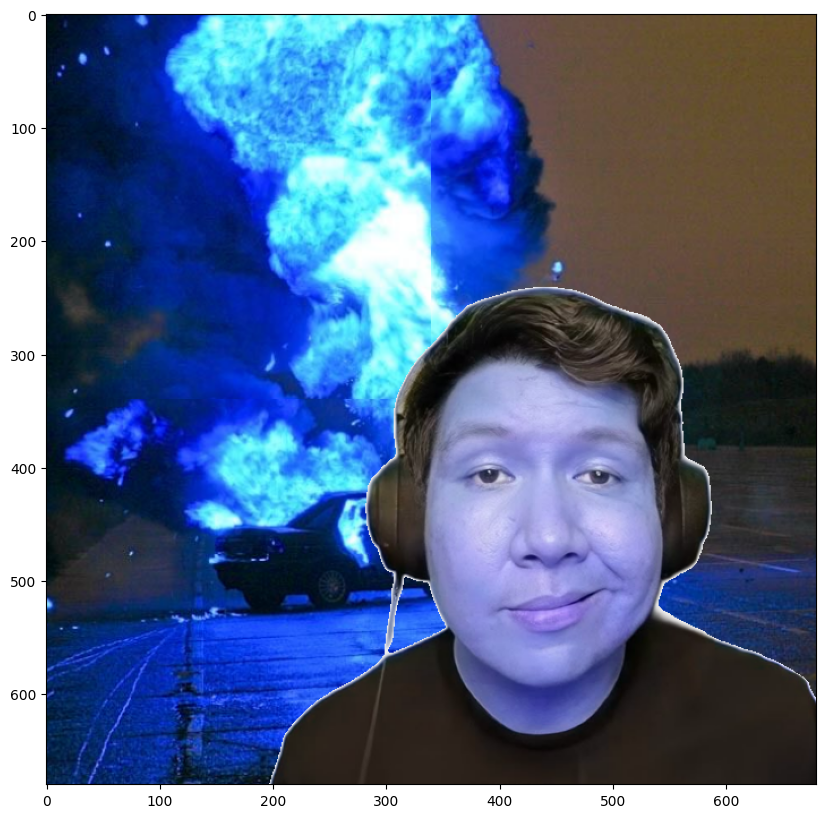

In [ ]:
windutCipularang = meledakM.copy()
windutCipularang = cv.cvtColor(windutCipularang, cv.COLOR_RGB2BGR)

for i in range(windutCipularang.shape[0]):
    for j in range(windutCipularang.shape[1]):
        if mask[i, j] == 0: 
            windutCipularang[i, j] = windutP[i, j]

plt.figure(figsize=(10, 10))
plt.imshow(windutCipularang, cmap = 'gray')

#### Menggabungkan meledakM dan windutP Menggunakan Masker

Proses ini dilakukan dengan `menyalin citra meledakM` ke variabel `windutCipularang` terlebih dahulu, lalu mengonversinya dari `format RGB ke BGR` menggunakan `cv.COLOR_RGB2BGR`. Kemudian setiap piksel diperiksa — jika nilai `mask[i, j] == 0` (area gelap), maka piksel `windutCipularang diisi dengan piksel dari windutP`, sedangkan jika `mask bernilai 1` (area terang) maka piksel tetap `berasal dari meledakM`. Tujuannya adalah untuk `mengganti area gelap` pada citra meledak dengan`piksel asli dari windutP`, sehingga hasil akhir `windutCipularang` merupakan `perpaduan dua citra` dimana `area terang dipertahankan dari meledakM` dan `area gelap diisi oleh windutP`.

## Kesimpulan

Pada praktikum ini telah dilakukan serangkaian operasi pengolahan citra yang saling berkaitan satu sama lain, mulai dari `ekualisasi histogram`, `spesifikasi histogram`, hingga `operasi masking`.

Proses diawali dengan `memotong dan menggabungkan citra meledak` menjadi satu menggunakan fungsi `merge()`, lalu diubah ke `grayscale` dan dilakukan `ekualisasi histogram` untuk meningkatkan kontrasnya. Hasil ekualisasi menunjukkan bahwa distribusi piksel yang sebelumnya `menumpuk di rentang sempit` berhasil `disebarkan secara merata` ke seluruh rentang intensitas 0–255.

Kemudian dilakukan `spesifikasi histogram` pada citra windut dengan dua citra referensi yang berbeda. Spesifikasi menggunakan `citra bunga (birengG)` menghasilkan distribusi yang `kurang ideal` karena karakteristik kedua citra yang sangat berbeda, sehingga sebagian besar piksel menumpuk pada satu nilai intensitas. Sebaliknya, spesifikasi menggunakan `citra langit (langitG)` menghasilkan distribusi yang `jauh lebih natural dan merata` karena karakteristik kecerahan keduanya lebih serupa.

Pada tahap `operasi masking`, dilakukan dua pendekatan. Pertama menggunakan `citra grayscale` dengan threshold 50 untuk memisahkan area terang dan gelap, lalu menggabungkan `windutS dan meledakE` menjadi citra yang lebih lengkap. Kedua menggunakan `citra berwarna` dengan threshold 240 berdasarkan rata-rata channel RGB untuk mendeteksi area langit, lalu menggabungkan `meledakM dan windutP` menjadi `windutCipularang`.

Secara keseluruhan, praktikum ini menunjukkan bahwa teknik `ekualisasi histogram`, `spesifikasi histogram`, dan `masking` merupakan operasi yang saling melengkapi dalam pengolahan citra. Hasil terbaik didapat ketika `citra referensi memiliki karakteristik distribusi yang serupa` dengan citra asal, dan `nilai threshold dipilih secara tepat` agar pemisahan area citra menghasilkan masker yang akurat.